# Fullmodel results — visualize across all medial mice

Loads `result/{mouse}_{date}_fullmodel_result.npz` for every mouse in `mouse_ids` and makes scatter plots over cortical position `(-ypos_plot, xpos_plot)` colored by:

- receptive-field x (`xpos_visual`)
- receptive-field y (`ypos_visual`)
- neural FECV (`FECV`)
- model FECV (`FECV_model`)

Each mouse gets its own row; columns are the four colorings.

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('/media/carsen/ssd1/github/oneshot')
from utils import data

mouse_ids = [0,1]
save_path = './result'
mouse_id = 4

In [11]:
# ---------- helper ----------
def p_to_stars(p):
    if p < 1e-3: return '***'
    if p < 1e-2: return '**'
    if p < 5e-2: return '*'
    return 'n.s.'

def add_bracket(ax, x1, x2, y, h, text, lw=1):
    """Draws a significance bracket from x1 to x2 at height y with height h."""
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, color='black')
    ax.text((x1+x2)/2, y+h, text, ha='center', va='bottom', fontsize=9)

In [12]:
inv_idx_all = np.zeros((len(mouse_ids), 2, 2))
inv_idx_all_model = np.zeros((len(mouse_ids), 2, 2))
rep_mat_all = np.zeros((len(mouse_ids), 2, 2, 32, 32))
rep_mat_all_model = np.zeros((len(mouse_ids), 2, 2, 32, 32))
sigvar_all = []
iarea_all = []
for i, mouse_id in enumerate(mouse_ids):
    fname = os.path.join(save_path, f'{data.db[mouse_id]["mname"]}_{data.db[mouse_id]["datexp"]}_fullmodel_result.npz')
    print('Loading result from:', fname)
    res_dict = np.load(fname, allow_pickle=True)
    ilayers = res_dict['ilayer'].astype(int)
    oneshot_spks = res_dict['oneshot_spks']
    oneshot_labels = res_dict['oneshot_labels']
    oneshot_model_pred = res_dict['oneshot_model_pred'][np.newaxis, ...]  # add batch dimension
    FEV = res_dict['oneshot_sigvar']
    sigvar_all.append(FEV)
    print(f'gabor FEVE (FEV>0.15): {np.mean(res_dict["gabor_feve"][res_dict["FEV"]>0.15])}')
    print(f'model FEVE (FEV>0.15): {np.mean(res_dict["FEVE_fullmodel"][res_dict["FEV"]>0.15])}')

    iareas = res_dict['iregion']
    iarea_all.append(iareas)
    iv1 = iareas == 0
    imedial = iareas == 1  

    # only use the top 10% FEV neurons from each area
    iv1 = iv1 & (FEV >= np.percentile(FEV[iv1], 90))
    imedial = imedial & (FEV >= np.percentile(FEV[imedial], 90))

    for iarea in range(2):
        for ilayer in range(2):
            # select top 10% FEV neurons from each area and layer
            select = (iareas == iarea) & (ilayers == ilayer+1) & (FEV >= np.percentile(FEV[(iareas == iarea) & (ilayers == ilayer+1)], 90))
            # print(f'mouse {mouse_id}, area {iarea}, layer {ilayer+1}, num neurons: {np.sum(select)}')
            
            # neural
            from utils.data import compute_invariance_df, compute_model_rep_mtx, compute_pair_inv_model
            oneshot_neural_df, rep_mat = compute_invariance_df(oneshot_spks[select], oneshot_labels, mouse_id=mouse_id)

            rep_mat_all[i, iarea, ilayer] = rep_mat
            inv_idx_all[i, iarea, ilayer] = np.mean(oneshot_neural_df['pair_invariance'])

            # model
            from scipy.stats import zscore
            model_pred_z = zscore(oneshot_model_pred[:, :, select], axis=1)
            # replace nan with 0 (if a neuron has zero variance, zscore will produce nan, but we want to keep it in the analysis and treat it as zero)
            model_pred_z = np.nan_to_num(model_pred_z)
            rep_mtx  = compute_model_rep_mtx(model_pred_z)
            oneshot_model_df = compute_pair_inv_model(rep_mtx)
            rep_mat_all_model[i, iarea, ilayer] = rep_mtx
            inv_idx_all_model[i, iarea, ilayer] = np.mean(oneshot_model_df['pair_invariance'])

Loading result from: ./result/TX104_2023_04_06_fullmodel_result.npz
gabor FEVE (FEV>0.15): -0.03251400753182011
model FEVE (FEV>0.15): -0.029453052655845486
Loading result from: ./result/TX110_2023_04_10_fullmodel_result.npz
gabor FEVE (FEV>0.15): -0.044891784875322305
model FEVE (FEV>0.15): -0.03470639498076023


In [13]:
sigvar_all = np.concatenate(sigvar_all)
iarea_all = np.concatenate(iarea_all)

print(sigvar_all.shape, iarea_all.shape)

(114161,) (114161,)


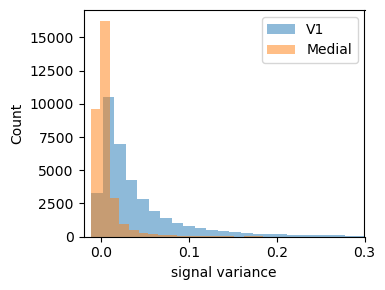

In [14]:
# distribution of sigvar for each area
area_names = ['V1', 'Medial']
fig, ax = plt.subplots(figsize=(4,3))
for iarea in range(2):
    ax.hist(sigvar_all[iarea_all==iarea], bins=50, alpha=0.5, label=f'{area_names[iarea]}')
ax.set_xlabel('signal variance')
ax.set_ylabel('Count')
ax.legend()
ax.set_xlim([-0.02, 0.3])
fig.tight_layout()  

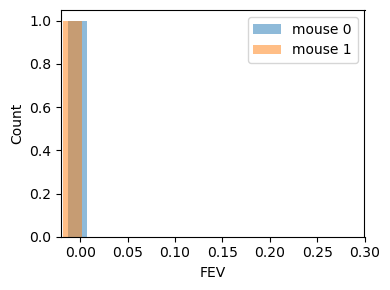

In [15]:
# plot the distribution of each day sigvar
fig, ax = plt.subplots(figsize=(4,3))
for i in range(len(mouse_ids)):
    ax.hist(sigvar_all[i], bins=50, alpha=0.5, label=f'mouse {mouse_ids[i]}')
ax.set_xlabel('FEV')
ax.set_ylabel('Count')
ax.legend()
ax.set_xlim([-0.02, 0.3])
fig.tight_layout()

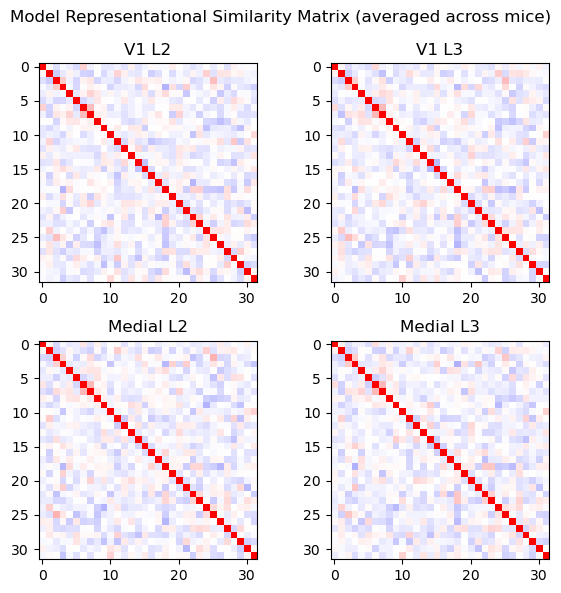

In [16]:
layer_names = ['L2', 'L3']
area_names = ['V1', 'Medial']

fig, ax = plt.subplots(2, 2, figsize=(6,6))
for iarea in range(2):
    for ilayer in range(2):
        ax[iarea, ilayer].imshow(rep_mat_all_model[:, iarea, ilayer].mean(axis=0), vmin=-1, vmax=1, cmap='bwr')
        ax[iarea, ilayer].set_title(f'{area_names[iarea]} {layer_names[ilayer]}')   
plt.suptitle('Model Representational Similarity Matrix (averaged across mice)')
plt.tight_layout()
plt.show()

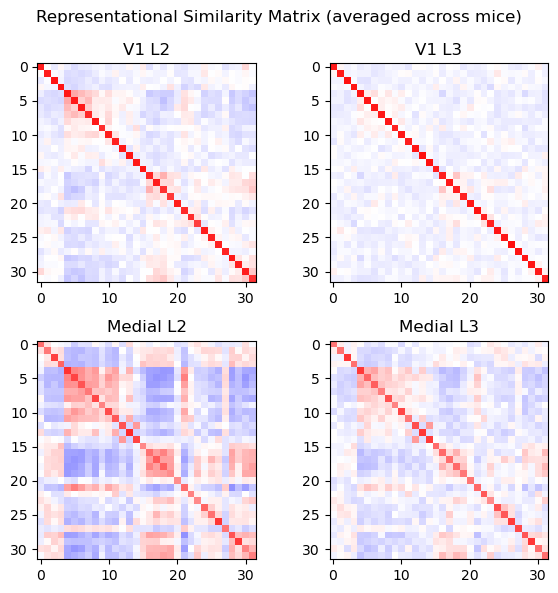

In [17]:
fig, ax = plt.subplots(2, 2, figsize=(6,6))
for iarea in range(2):
    for ilayer in range(2):
        ax[iarea, ilayer].imshow(rep_mat_all[:, iarea, ilayer].mean(axis=0), vmin=-1, vmax=1, cmap='bwr')
        ax[iarea, ilayer].set_title(f'{area_names[iarea]} {layer_names[ilayer]}')   
plt.suptitle('Representational Similarity Matrix (averaged across mice)')
plt.tight_layout()
plt.show()

paired t-test between layers in area 0, t=-0.05679222024599856, p=0.9638837455968486
paired t-test between layers in area 1, t=-0.28515344742199167, p=0.8231590775885562
paired t-test between areas, t=0.4828204819887974, p=0.6622650826667327


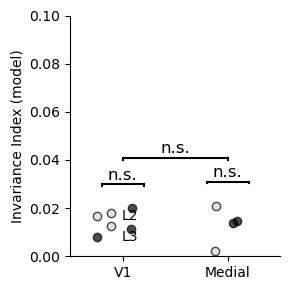

In [18]:
# plot the sigma 
nmouse = len(mouse_ids)
varplot = inv_idx_all_model.copy() # mouse, area, layer
fig, ax = plt.subplots(figsize=(3,3))
# scatter plot of each mouse, xaxies is V1 and medial, layer is with different color with a small shift in x axis
depth_colors = ['lightgray', 'black']
for ilayer in range(2):
    for iarea in range(2):
        ax.scatter(np.ones(nmouse)*iarea + (ilayer-0.5)*0.2 + np.random.randn(nmouse)*0.02, varplot[:, iarea, ilayer], color=depth_colors[ilayer], alpha=0.7, label=layer_names[ilayer] if iarea==0 else "", edgecolor='black')
        # plot the median
        # ax.scatter(iarea + (ilayer-0.5)*0.1, np.nanmedian(varplot[:, iarea, ilayer]), color=depth_colors[ilayer], s=100, edgecolor='black', marker='D')
from scipy import stats
for iarea in range(2):
    # stats of difference between layers with paired t-test
    t, p = stats.ttest_rel(varplot[:,iarea,0], varplot[:,iarea,1])
    print(f'paired t-test between layers in area {iarea}, t={t}, p={p}')
    # plot the stars for significance based on p value
    ymax = np.nanmax(varplot[:,iarea,:])+0.01
    ax.plot([iarea-0.2, iarea+0.2], [ymax, ymax], color='black')
    # plot the small bar 
    ax.plot([iarea-0.2, iarea-0.2], [ymax*0.98, ymax], color='black')
    ax.plot([iarea+0.2, iarea+0.2], [ymax*0.98, ymax], color='black')
    ax.text(iarea, ymax*1.02, p_to_stars(p), ha='center', va='bottom', color='black', fontsize=12)

t, p = stats.ttest_rel(varplot[:,0,:].flatten(), varplot[:,1,:].flatten())
print(f'paired t-test between areas, t={t}, p={p}')
ymax = np.nanmax(varplot)+0.02
ax.plot([0,1], [ymax, ymax], color='black')
ax.text(0.5, ymax*1.02, p_to_stars(p), ha='center', va='bottom', color='black', fontsize=12)
# plot the small bar
ax.plot([0,0], [ymax*0.98, ymax], color='black')
ax.plot([1,1], [ymax*0.98, ymax], color='black')

ax.set_xticks([0,1])
ax.set_xticklabels(area_names)
ax.set_ylabel('Invariance Index (model)')
ax.legend(loc='lower left', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim([-0.5, 1.5])
ax.set_ylim([0, 0.1])
fig.tight_layout()

paired t-test between layers in area 0, t=1.479202902605743, p=0.3784473063346916
paired t-test between layers in area 1, t=1.6903363837046566, p=0.3400942623092549
paired t-test between areas, t=-2.994741279923499, p=0.05791112922325984


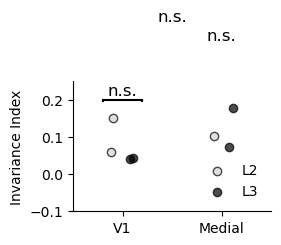

In [19]:
# plot the sigma 
nmouse = len(mouse_ids)
varplot = inv_idx_all
fig, ax = plt.subplots(figsize=(3,3))
# scatter plot of each mouse, xaxies is V1 and medial, layer is with different color with a small shift in x axis
depth_colors = ['lightgray', 'black']
for ilayer in range(2):
    for iarea in range(2):
        ax.scatter(np.ones(nmouse)*iarea + (ilayer-0.5)*0.2 + np.random.randn(nmouse)*0.02, varplot[:, iarea, ilayer], color=depth_colors[ilayer], alpha=0.7, label=layer_names[ilayer] if iarea==0 else "", edgecolor='black')
        # plot the median
        # ax.scatter(iarea + (ilayer-0.5)*0.1, np.nanmedian(varplot[:, iarea, ilayer]), color=depth_colors[ilayer], s=100, edgecolor='black', marker='D')
from scipy import stats
for iarea in range(2):
    # stats of difference between layers with paired t-test
    t, p = stats.ttest_rel(varplot[:,iarea,0], varplot[:,iarea,1])
    print(f'paired t-test between layers in area {iarea}, t={t}, p={p}')
    # plot the stars for significance based on p value
    ymax = np.nanmax(varplot[:,iarea,:])+0.05
    ax.plot([iarea-0.2, iarea+0.2], [ymax, ymax], color='black')
    # plot the small bar 
    ax.plot([iarea-0.2, iarea-0.2], [ymax*0.98, ymax], color='black')
    ax.plot([iarea+0.2, iarea+0.2], [ymax*0.98, ymax], color='black')
    ax.text(iarea, ymax*1.02, p_to_stars(p), ha='center', va='bottom', color='black', fontsize=12)

t, p = stats.ttest_rel(varplot[:,0,:].flatten(), varplot[:,1,:].flatten())
print(f'paired t-test between areas, t={t}, p={p}')
ymax = np.nanmax(varplot)+0.1
ax.plot([0,1], [ymax, ymax], color='black')
ax.text(0.5, ymax*1.02, p_to_stars(p), ha='center', va='bottom', color='black', fontsize=12)
# plot the small bar
ax.plot([0,0], [ymax*0.98, ymax], color='black')
ax.plot([1,1], [ymax*0.98, ymax], color='black')

ax.set_xticks([0,1])
ax.set_xticklabels(area_names)
ax.set_ylabel('Invariance Index')
ax.legend(loc='lower right', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim([-0.5, 1.5])
ax.set_ylim([-0.1, 0.25])
fig.tight_layout()

# retinotopy

In [20]:
# xpos_visual = xmax*2*(270/264) - 135 # 0 is at the center, so it should be 135 pixels
# ypos_visual = ymax*2*(65/66) - 32.5 # vertical visual range is 65, so it sould be (66/65) pixels per degree
# xpos_plot, ypos_plot  = xpos/pix_res[0], ypos/pix_res[1]

valid_idxes = np.where(test_fev > 0.)[0]
vmin_x = -135
vmax_x = 270 * (hmax_angle/88)-135
vmin_y = -32.5
vmax_y = 65*(25/22)-32.5
plot_boundary = True
fig, ax = plt.subplots(1, 5, figsize=(20, 3))
ax[0].scatter(-ypos_plot, xpos_plot, s=10, c='gray', alpha=0.5)
sc = ax[0].scatter(-ypos_plot, xpos_plot, c=xpos_visual, s=10, cmap='gist_ncar', vmin=vmin_x, vmax=vmax_x, rasterized=True)
cbar = fig.colorbar(sc, ax=ax[0], fraction=0.02, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('x visual angle (deg)')
ax[0].set_title(f'mouse {mouse_id+1} ({data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]})\n xpos range: {np.max(xpos_plot)-np.min(xpos_plot)}, ypos range: {np.max(ypos_plot)-np.min(ypos_plot)}', loc='center')
ax[0].set_aspect('equal', adjustable='box')

# ax.set_axis_off()
# fig.savefig(f'./outputs/{data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}_xpos_visual.png', dpi=300, bbox_inches='tight')
# plt.close(fig)
ax[1].scatter(-ypos_plot, xpos_plot, s=10, c='gray', alpha=0.5)
sc = ax[1].scatter(-ypos_plot, xpos_plot, c=ypos_visual, s=10, cmap='gist_ncar', vmin=vmin_y, vmax=vmax_y, rasterized=True)
cbar = fig.colorbar(sc, ax=ax[1], fraction=0.03, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('y visual angle (deg)')   
ax[1].set_title(f'mouse {mouse_id+1} ({data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]})\n xpos range: {np.max(xpos_plot)-np.min(xpos_plot)}, ypos range: {np.max(ypos_plot)-np.min(ypos_plot)}', loc='center')
ax[1].set_aspect('equal', adjustable='box')
# ax[1].plot([point1[0], point2[0]], [point1[1], point2[1]], 'r--', linewidth=5)

ax[2].scatter(-ypos_plot, xpos_plot, s=10, c='gray', alpha=0.5)
sc = ax[2].scatter(-ypos_plot[valid_idxes], xpos_plot[valid_idxes], c=test_fev[valid_idxes], s=10, cmap='viridis', vmin=0, vmax=0.5)
cbar = fig.colorbar(sc, ax=ax[2], fraction=0.02, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('FEV')
ax[2].set_title(f'mouse {mouse_id+1} FEV', loc='center')
ax[2].set_aspect('equal', adjustable='box')
# ax[2].plot([point1[0], point2[0]], [point1[1], point2[1]], 'r--', linewidth=5)

ax[3].scatter(-ypos_plot, xpos_plot, s=10, c='gray', alpha=0.5)
sc = ax[3].scatter(-ypos_plot[valid_idxes], xpos_plot[valid_idxes], c=test_feve[valid_idxes], s=10, cmap='viridis', vmin=0, vmax=1)
cbar = fig.colorbar(sc, ax=ax[3], fraction=0.02, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('FEVE')
ax[3].set_title(f'mouse {mouse_id+1} FEVE', loc='center')
ax[3].set_aspect('equal', adjustable='box')

ax[4].scatter(-ypos_plot, xpos_plot, s=10, c='gray', alpha=0.5)
sc = ax[4].scatter(-ypos_plot[valid_idxes], xpos_plot[valid_idxes], c=rf_size[valid_idxes], s=10, cmap='viridis', vmin=0, vmax=25)
cbar = fig.colorbar(sc, ax=ax[4], fraction=0.02, pad=0.04)
cbar.outline.set_visible(False)
cbar.set_label('RF size (deg)')
ax[4].set_title(f'mouse {mouse_id+1} rf size', loc='center')
ax[4].set_aspect('equal', adjustable='box')
# ax[4].scatter(-ypos_plot[iv1], xpos_plot[iv1], s=10, c='red', alpha=0.5, label='model')

if plot_boundary:
    for i in range(5):
        ax[i].plot([point1[0], point2[0]], [point1[1], point2[1]], 'r--', linewidth=5)
# ax[3].plot([point1[0], point2[0]], [point1[1], point2[1]], 'r--', linewidth=5)
plt.tight_layout()


NameError: name 'test_fev' is not defined

# invariance index

In [ ]:
fname = os.path.join(save_path, f'{data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}_fullmodel_result.npz')
res_dict = np.load(fname, allow_pickle=True)
oneshot_spks = res_dict['oneshot_spks']
oneshot_labels = res_dict['oneshot_labels']
oneshot_model_pred = res_dict['oneshot_model_pred'][np.newaxis, ...]  # add batch dimension

iarea = res_dict['iarea']
iv1 = iarea == 0
imedial = iarea == 1

# only use the top 10% FEV neurons from each area
iv1 = iv1 & (res_dict['FEV'] >= np.percentile(res_dict['FEV'][iv1], 90))
imedial = imedial & (res_dict['FEV'] >= np.percentile(res_dict['FEV'][imedial], 90))

In [ ]:
print(oneshot_spks.shape, oneshot_labels.shape, oneshot_model_pred.shape)

(4180, 3199) (3199,) (1, 32, 4180)


In [ ]:
from scipy.stats import zscore
spks = zscore(oneshot_spks[imedial], axis=1)

instances, nc = np.unique(oneshot_labels, return_counts=True)
nreps = np.min(nc)
NN = spks.shape[0]
n_inst = len(instances)

stim_response = np.zeros((NN, n_inst, nreps))
for i, inst in enumerate(instances):
    idx = np.where(oneshot_labels == inst)[0]
    idx = np.random.permutation(idx)[:nreps]
    stim_response[:, i, :] = spks[:, idx]

In [ ]:
first_h = nreps // 2
rep_mat = np.zeros((n_inst, n_inst))
for i in range(n_inst):
    fh = stim_response[:, i, :first_h].mean(axis=1)
    sh = stim_response[:, i, first_h:].mean(axis=1)
    rep_mat[i, i] = np.corrcoef(fh, sh)[0, 1]

In [ ]:
from itertools import combinations
for i, j in combinations(range(n_inst), 2):
    a = stim_response[:, i, :].mean(axis=1)
    b = stim_response[:, j, :].mean(axis=1)
    c = np.corrcoef(a, b)[0, 1]
    rep_mat[i, j] = rep_mat[j, i] = c

In [ ]:
# plt.imshow(rep_mat, vmin=-1, vmax=1, cmap='bwr')

In [ ]:
# neural
from utils.data import compute_invariance_df, compute_model_rep_mtx, compute_pair_inv_model
oneshot_neural_df_v1, condensed_mat_v1 = compute_invariance_df(oneshot_spks[iv1], oneshot_labels, mouse_id=mouse_id)
oneshot_neural_df_medial, condensed_mat_medial = compute_invariance_df(oneshot_spks[imedial], oneshot_labels, mouse_id=mouse_id)

# model
rep_mtx_v1  = compute_model_rep_mtx(oneshot_model_pred[:, :, iv1])
oneshot_model_df_v1 = compute_pair_inv_model(rep_mtx_v1)

rep_mtx_medial  = compute_model_rep_mtx(oneshot_model_pred[:, :, imedial])
oneshot_model_df_medial = compute_pair_inv_model(rep_mtx_medial)

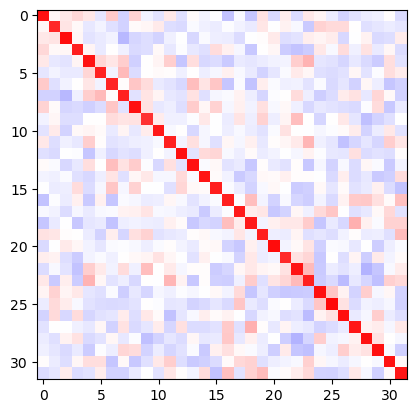

In [ ]:
plt.imshow(condensed_mat_v1, vmin=-1, vmax=1, cmap='bwr')

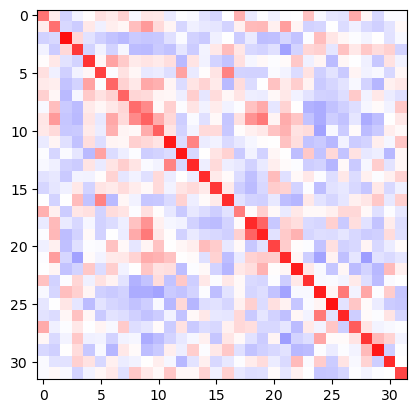

In [ ]:
plt.imshow(condensed_mat_medial, vmin=-1, vmax=1, cmap='bwr')

T-statistic: -0.5928, P-value: 5.5580e-01


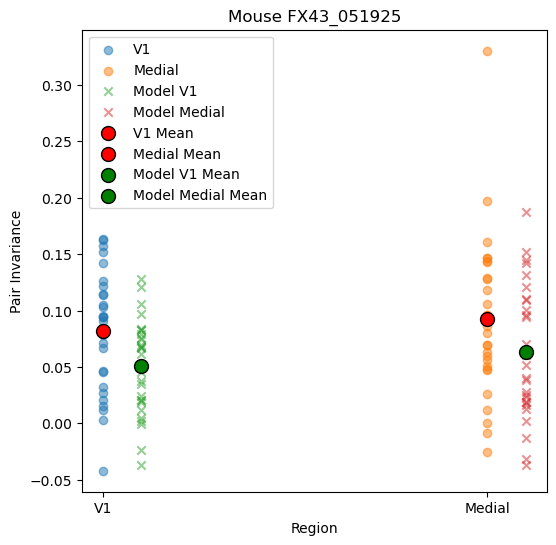

In [ ]:
# compare the pair invariance between V1 and medial
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(np.ones(len(oneshot_neural_df_v1)) * 0, oneshot_neural_df_v1['pair_invariance'], label='V1', alpha=0.5)
ax.scatter(np.ones(len(oneshot_neural_df_medial)) * 1, oneshot_neural_df_medial['pair_invariance'], label='Medial', alpha=0.5)
ax.scatter(np.ones(len(oneshot_model_df_v1)) * 0 + 0.1, oneshot_model_df_v1['pair_invariance'], label='Model V1', alpha=0.5, marker='x')
ax.scatter(np.ones(len(oneshot_model_df_medial)) * 1 + 0.1, oneshot_model_df_medial['pair_invariance'], label='Model Medial', alpha=0.5, marker='x')

# plot the mean
ax.scatter(0, oneshot_neural_df_v1['pair_invariance'].mean(), color='red', label='V1 Mean', edgecolor='black', s=100)
ax.scatter(1, oneshot_neural_df_medial['pair_invariance'].mean(), color='red', label='Medial Mean', edgecolor='black', s=100)
ax.scatter(0.1, oneshot_model_df_v1['pair_invariance'].mean(), color='green', label='Model V1 Mean', edgecolor='black', s=100)
ax.scatter(1.1, oneshot_model_df_medial['pair_invariance'].mean(), color='green', label='Model Medial Mean', edgecolor='black', s=100)
# ttest
from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(oneshot_neural_df_v1['pair_invariance'], oneshot_neural_df_medial['pair_invariance'])
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4e}")

ax.set_xticks([0, 1])
ax.set_xticklabels(['V1', 'Medial'])
ax.set_ylabel('Pair Invariance')
ax.set_title(f'Mouse {data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}')
ax.set_xlabel('Region')
ax.legend()
plt.show()

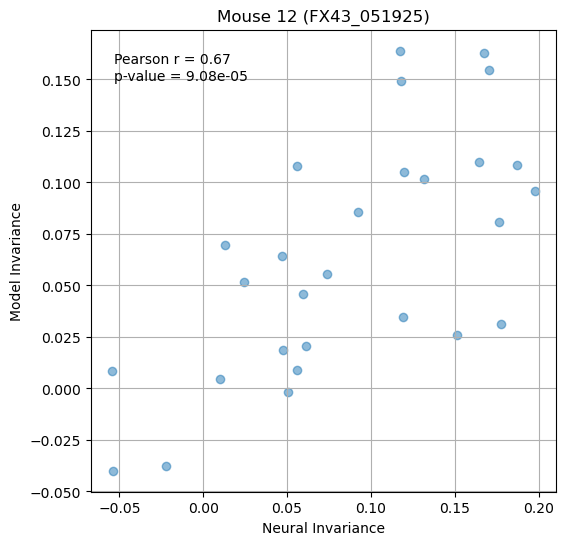

In [ ]:
# scatter plot of neural vs model invariance
plt.figure(figsize=(6, 6))
plt.scatter(oneshot_neural_df['pair_invariance'], oneshot_model_df['pair_invariance'], alpha=0.5)
plt.xlabel('Neural Invariance')
plt.ylabel('Model Invariance')
plt.title(f'Mouse {mouse_id} ({data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]})')
plt.grid(True)
# show correlation and p-value
from scipy.stats import pearsonr
corr, pval = pearsonr(oneshot_neural_df['pair_invariance'], oneshot_model_df['pair_invariance'])
plt.text(0.05, 0.95, f'Pearson r = {corr:.2f}\np-value = {pval:.2e}', transform=plt.gca().transAxes, verticalalignment='top')
plt.show()

## Load fullmodel results

In [ ]:
results = {}
for mouse_id in mouse_ids:
    fname = os.path.join(save_path, f'{data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}_fullmodel_result.npz')
    res = np.load(fname, allow_pickle=True)
    results[mouse_id] = {
        'xpos_plot':   res['xpos_plot'].astype(float),
        'ypos_plot':   res['ypos_plot'].astype(float),
        'xpos_visual': res['xpos_visual'].astype(float),
        'ypos_visual': res['ypos_visual'].astype(float),
        'FECV':        res['FECV'].astype(float),
        'FECV_model':  res['FECV_model'].astype(float),
        'FEV':        res['FEV'].astype(float),
        'FEVE':       res['FEVE'].astype(float),
        'oneshot_spks': res['oneshot_spks'].astype(float),
        'oneshot_labels': res['oneshot_labels'].astype(int),
        'oneshot_model_pred': res['oneshot_model_pred'].astype(float),
    }
    print(f"mouse {mouse_id} ({data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}): n_neurons = {len(res['xpos_plot'])}")

KeyError: 'FEVE is not a file in the archive'

## Scatter plots — one row per mouse, one column per coloring

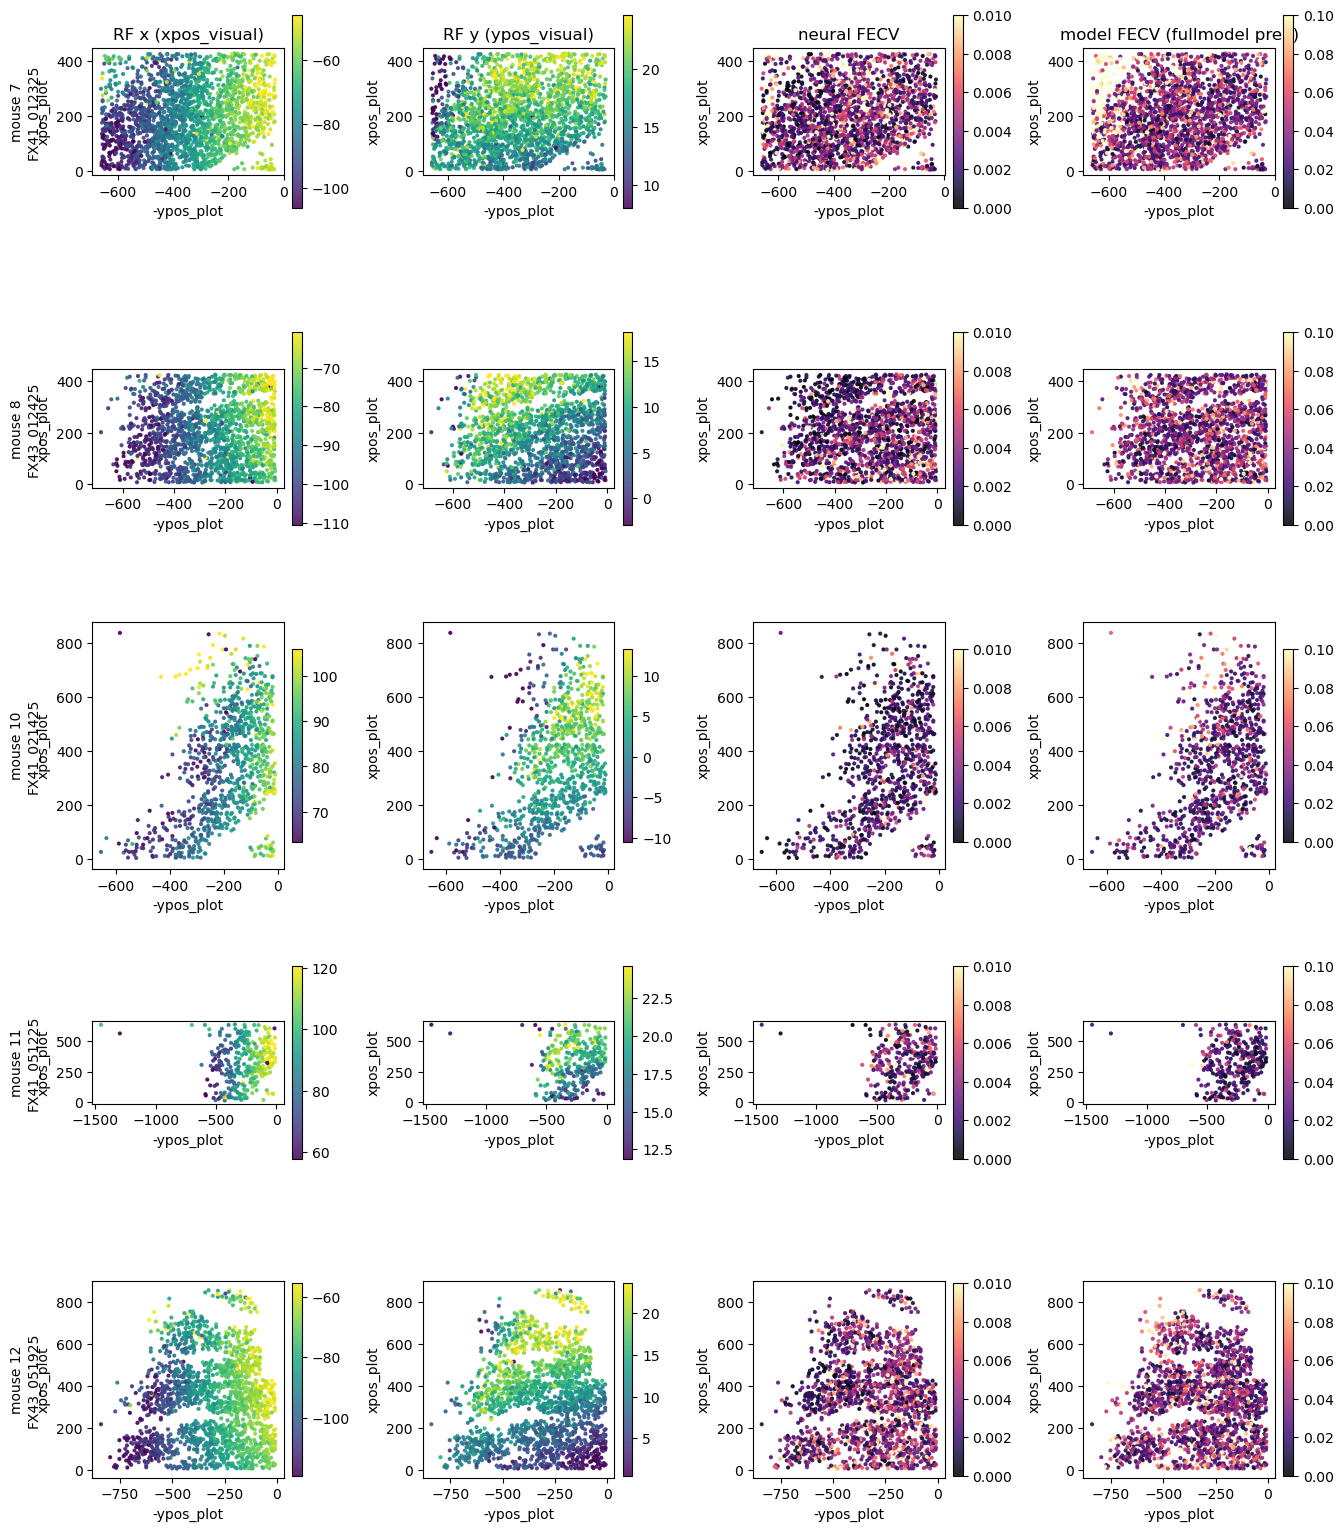

In [ ]:
color_specs = [
    ('xpos_visual', 'RF x (xpos_visual)', 'viridis', None),
    ('ypos_visual', 'RF y (ypos_visual)', 'viridis', None),
    ('FECV',        'neural FECV',         'magma',   (0, 0.01)),
    ('FECV_model',  'model FECV (fullmodel pred)', 'magma', (0, 0.1)),
]

n_rows = len(mouse_ids)
n_cols = len(color_specs)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.4 * n_cols, 3.2 * n_rows), squeeze=False)

for i, mouse_id in enumerate(mouse_ids):
    r = results[mouse_id]
    x = -r['ypos_plot']
    y =  r['xpos_plot']
    for j, (key, title, cmap, vlim) in enumerate(color_specs):
        ax = axes[i, j]
        c = r[key]
        if vlim is None:
            finite = c[np.isfinite(c)]
            vmin, vmax = (np.percentile(finite, 2), np.percentile(finite, 98)) if finite.size else (None, None)
        else:
            vmin, vmax = vlim
        sc = ax.scatter(x, y, c=c, s=4, cmap=cmap, vmin=vmin, vmax=vmax, alpha=0.85)
        ax.set_aspect('equal')
        ax.set_xlabel('-ypos_plot')
        ax.set_ylabel('xpos_plot')
        if i == 0:
            ax.set_title(title)
        if j == 0:
            ax.text(-0.35, 0.5, f'mouse {mouse_id}\n{data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}',
                    transform=ax.transAxes, rotation=90, ha='center', va='center')
        plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()

## Neural vs model FECV — all mice combined

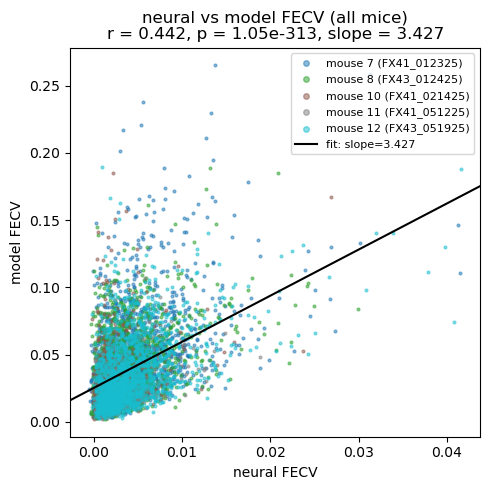

In [ ]:
from scipy.stats import pearsonr, linregress

fig, ax = plt.subplots(figsize=(5, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(mouse_ids)))

all_neural = []
all_model = []
for mouse_id, color in zip(mouse_ids, colors):
    r = results[mouse_id]
    ax.scatter(r['FECV'], r['FECV_model'], s=4, alpha=0.5, color=color,
               label=f'mouse {mouse_id} ({data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]})')
    all_neural.append(r['FECV'])
    all_model.append(r['FECV_model'])

all_neural = np.concatenate(all_neural)
all_model = np.concatenate(all_model)
mask = np.isfinite(all_neural) & np.isfinite(all_model)
x_all = all_neural[mask]
y_all = all_model[mask]

rval, pval = pearsonr(x_all, y_all)
slope, intercept, _, _, _ = linregress(x_all, y_all)

xlim = ax.get_xlim()
ylim = ax.get_ylim()
xx = np.array(xlim)
ax.plot(xx, slope * xx + intercept, 'k-', lw=1.5,
        label=f'fit: slope={slope:.3f}')
ax.set_xlim(xlim)
ax.set_ylim(ylim)
# ax.set_aspect('equal')
ax.set_xlabel('neural FECV')
ax.set_ylabel('model FECV')
ax.set_title(f'neural vs model FECV (all mice)\nr = {rval:.3f}, p = {pval:.2e}, slope = {slope:.3f}')
ax.legend(fontsize=8, markerscale=2)
fig.tight_layout()
plt.show()